In [6]:
%pip install ipympl
%matplotlib widget

Note: you may need to restart the kernel to use updated packages.


In [7]:
from enum import auto
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import stft
from scipy.fft import fft, fftfreq, fftshift, ifft

In [8]:
def transform(file_name):
    sample_rate, data = wavfile.read(file_name)
    left_data = data[:, 0]
    right_data = data[:, 1]
    
    f_transform_left = fft(left_data)
    f_left = fftfreq(len(left_data), 1/sample_rate)
    amplitude_left = np.abs(f_transform_left) / (len(left_data) / 2)

    f_transform_right = fft(right_data)
    f_right = fftfreq(len(right_data), 1/sample_rate)
    amplitude_right = np.abs(f_transform_right) / (len(right_data) / 2)

    return left_data, f_transform_left, f_left, amplitude_left, right_data, f_transform_right, f_right, amplitude_right, sample_rate

In [9]:
def plot(x, y, title, xlabel, ylabel):
    plt.figure(figsize=(10, 4))
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xlabel(xlabel)
    plt.plot(x, y)
    plt.tight_layout()
    plt.show()


C:\Users\eranm\AppData\Local\Temp\ipykernel_16468\730090391.py:2: WavFileWarning: Reached EOF prematurely; finished at 39342193 bytes, expected 4294967303 bytes from header.
  sample_rate, data = wavfile.read(file_name)


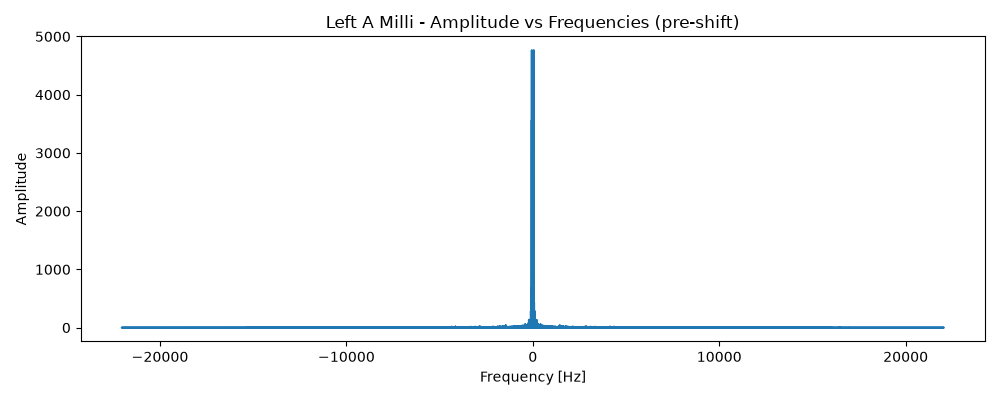

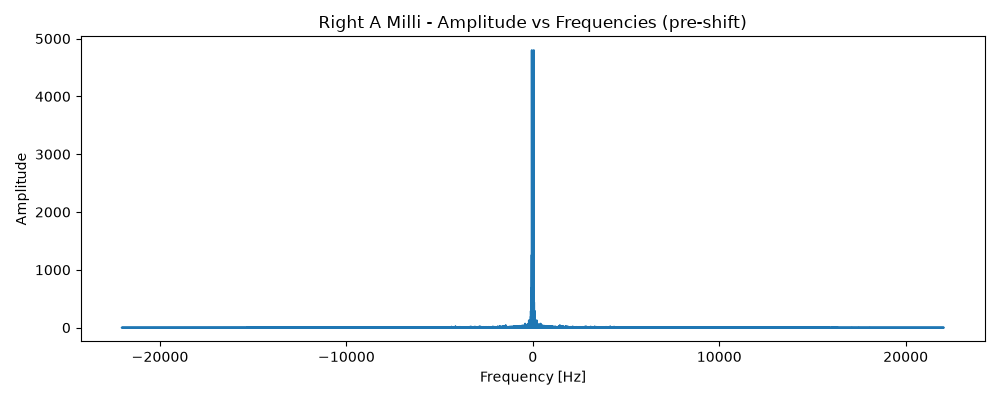

In [10]:
right_limit = 23000

left_data, f_transform_left, f_left, amplitude_left, right_data, f_transform_right, f_right, amplitude_right, sample_rate = transform('a_milli.wav')
plot(f_left, amplitude_left,  'Left A Milli - Amplitude vs Frequencies (pre-shift)', 'Frequency [Hz]', 'Amplitude')
plot(f_right, amplitude_right,  'Right A Milli - Amplitude vs Frequencies (pre-shift)', 'Frequency [Hz]', 'Amplitude')

In [11]:
def remove_dc_offset(f_transform, data):
    f_transform[0] = 0
    amplitude = np.abs(f_transform) / (len(data) / 2)
    return amplitude

In [24]:
def inverse_transform(left, right, sample_rate, output_filename):
    reconstructed_left = ifft(left)
    reconstructed_right = ifft(right)

    reconstructed_left_real = np.real(reconstructed_left)
    reconstructed_right_real = np.real(reconstructed_right)
  
    reconstructed_real = reconstructed = np.stack((reconstructed_left_real, reconstructed_right_real), axis=1)
    audio_data_int16 = np.int16(reconstructed_real * 32767)
    
    wavfile.write(output_filename, sample_rate, audio_data_int16)

    return reconstructed_real

32767.000000000025


C:\Users\eranm\AppData\Local\Temp\ipykernel_16468\799546152.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10, 4))


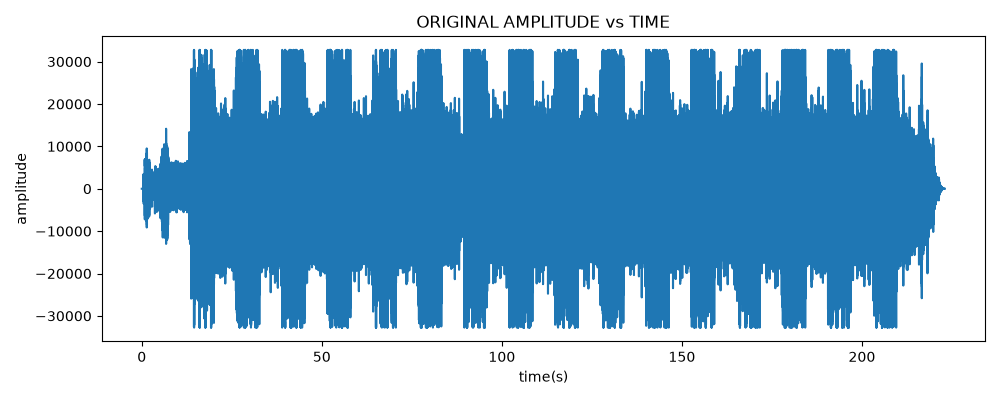

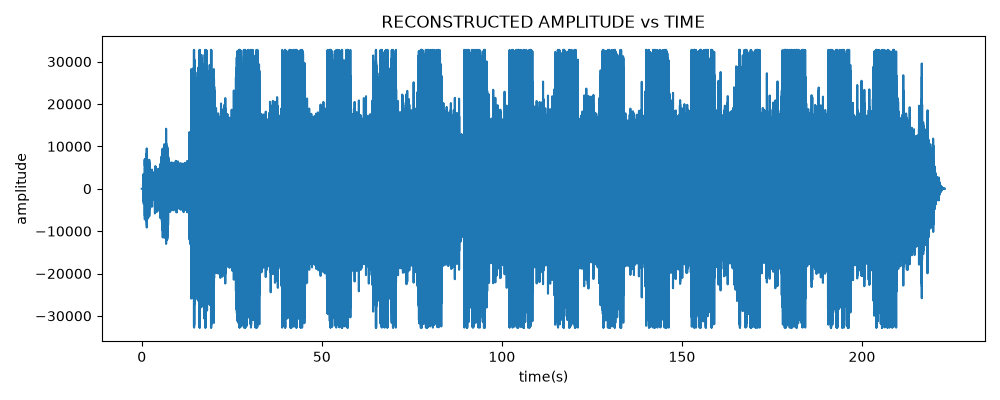

In [ ]:
reconstructed_data = inverse_transform(f_transform_left, f_transform_right, sample_rate, 'reconstructed.wav')
original_data = np.stack((left_data, right_data), axis=1)
delta = reconstructed_data - original_data
reconstructed_ld = reconstructed_data[:, 0]
duration = len(original_data) / sample_rate
time = np.linspace(0.0, duration, num=len(original_data))


plot(time, left_data, 'ORIGINAL AMPLITUDE vs TIME', 'time(s)', 'amplitude')
plot(time, reconstructed_ld, 'RECONSTRUCTED AMPLITUDE vs TIME', 'time(s)', 'amplitude')